# ACLAB CV-01 Challenge | Pixels, Channels & ROI

Work with a real image as a NumPy array.

In this challenge you will inspect image data, swap color channels, and edit a Region of Interest (ROI).

Read the CV-01 lesson PDF before starting.


## Challenge

Complete these tasks:

1. Print the image shape, dtype, and one pixel value.
2. Swap the **red and blue channels**.
3. Replace the given ROI with the **mean color of that ROI**.
4. Show the original and final images side by side.
5. Save the final result to `/kaggle/working/cv01_output.png`.

### Rules

- Use NumPy operations for the required image manipulation.
- Do not use a blur function for the ROI operation.
- Do not overwrite the original `image`.
- Keep the required variable names used by the validation cells.


## Setup


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Create a small sample RGB image so this notebook is self-contained.
H, W = 240, 320
yy, xx = np.mgrid[0:H, 0:W]

sample = np.zeros((H, W, 3), dtype=np.uint8)
sample[..., 0] = np.clip(40 + xx * 0.55, 0, 255).astype(np.uint8)
sample[..., 1] = np.clip(30 + yy * 0.75, 0, 255).astype(np.uint8)
sample[..., 2] = np.clip(220 - xx * 0.35, 0, 255).astype(np.uint8)

# Add a few regions so channel and ROI changes are easy to see.
sample[35:105, 35:120] = [220, 55, 45]
sample[125:205, 70:155] = [45, 190, 80]
sample[55:170, 205:285] = [60, 105, 230]

INPUT_PATH = "/kaggle/working/cv01_input.png"
Image.fromarray(sample).save(INPUT_PATH)

image = np.array(Image.open(INPUT_PATH).convert("RGB"), dtype=np.uint8)
_original_reference = image.copy()

# Fixed ROI used for validation: (x1, y1, x2, y2)
ROI = (80, 60, 240, 180)

print("Input ready:", image.shape, image.dtype)


Input ready: (240, 320, 3) uint8


## Student code

Keep these variable names:

- `channel_swapped`
- `result`

The ROI is given as `(x1, y1, x2, y2)`.


In [4]:
# ==============================
# STUDENT CODE
# ==============================

print("Shape:", image.shape)
print("dtype:", image.dtype)
print("Pixel [100, 120] before:", image[100, 120])

# 1. Swap the red and blue channels.
channel_swapped = image[..., [2, 1, 0]]

# 2. Make a copy and replace the given ROI
#    with the mean color of that ROI.
result = channel_swapped.copy()

# YOUR CODE HERE
x1, y1, x2, y2 = ROI
roi = result[y1:y2, x1:x2]
mean_color = roi.mean(axis=(0,1)).astype(np.uint8)
result[y1:y2, x1:x2] = mean_color

# Print the same pixel after your modification if it lies in
# an area that changed, or print another useful pixel.
print("Pixel [100,120] after:", result[100,120])

Shape: (240, 320, 3)
dtype: uint8
Pixel [100, 120] before: [106 105 178]
Pixel [100,120] after: [147 123 106]


## Validation


In [5]:
if channel_swapped is None or result is None:
    print(
        "Challenge not completed yet. "
        "Complete the STUDENT CODE section first."
    )
else:
    assert isinstance(channel_swapped, np.ndarray),         "channel_swapped must be a NumPy array."
    assert isinstance(result, np.ndarray),         "result must be a NumPy array."

    assert channel_swapped.shape == image.shape,         "channel_swapped must keep the original image shape."
    assert result.shape == image.shape,         "result must keep the original image shape."

    assert channel_swapped.dtype == np.uint8,         "channel_swapped must use uint8."
    assert result.dtype == np.uint8,         "result must use uint8."

    # The original image must stay unchanged.
    assert np.array_equal(image, _original_reference),         "Do not overwrite the original image."

    # Red and blue channels must be swapped.
    expected_swapped = image[..., [2, 1, 0]]
    assert np.array_equal(channel_swapped, expected_swapped),         "Red and blue channels were not swapped correctly."

    x1, y1, x2, y2 = ROI
    roi_before = channel_swapped[y1:y2, x1:x2]
    mean_color = roi_before.mean(axis=(0, 1)).astype(np.uint8)

    # Every pixel inside the ROI should equal the mean color.
    expected_roi = np.empty_like(roi_before)
    expected_roi[:] = mean_color
    assert np.array_equal(result[y1:y2, x1:x2], expected_roi),         "The ROI was not replaced with its mean color."

    # Outside the ROI, result should be unchanged from channel_swapped.
    outside_mask = np.ones(image.shape[:2], dtype=bool)
    outside_mask[y1:y2, x1:x2] = False
    assert np.array_equal(
        result[outside_mask],
        channel_swapped[outside_mask]
    ), "Pixels outside the ROI should not change."

    print("Basic checks passed.")


Basic checks passed.


## Final output


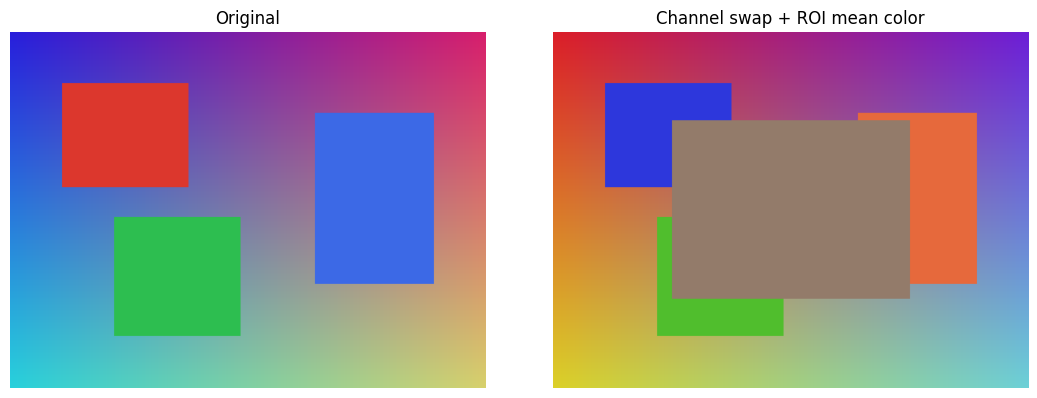

In [6]:
if result is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(result)
    axes[1].set_title("Channel swap + ROI mean color")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


## Save output


In [7]:
if result is not None:
    OUTPUT_PATH = "/kaggle/working/cv01_output.png"
    plt.imsave(OUTPUT_PATH, result)

    assert os.path.exists(OUTPUT_PATH),         "cv01_output.png was not created."

    print("Saved:", OUTPUT_PATH)


Saved: /kaggle/working/cv01_output.png


## Submission

1. Run all cells.
2. Make sure all checks pass.
3. Make sure the final comparison is visible.
4. Click **Save Version → Save & Run All**.
5. Share your Kaggle notebook.
6. Submit the notebook URL through the course submission form.
